# Project Workflow
### Analysis Breakdown
- Data Import
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Feature Selection
- Train-Test Split
- Model Building
- Cross Validation
- Model Comparison
- Feature importance
- Model Interpretation
- Conclusion

## Data Import

In [4]:
# Import the required libraries
import warnings
warnings.filterwarnings("ignore")

# Dataset baseline library
import pandas as pd
import numpy as np

#Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tool
from scipy import stats

# Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.metrics import (
           r2_score,
           mean_squared_error,
           mean_absolute_error)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Setting the layers
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully")

Libraries imported successfully


## Data Cleaning

In [5]:
# Load CSV file into a DataFrame and inspect the dataset
file_path = r"C:\Users\chukw\Downloads\phytoremediation_dataset.csv"
df = pd.read_csv(file_path)
df

,Plant,Metal,Week,C0_soil_initial mg/kg,Soil (So) mg/kg,Root (Ro) mg/kg,Leaf (Le) mg/kg,TF,pH,CEC cmol(+)/kg,OC g/kg,Soil mass (kg),HM_x,HM_r nm,Yield kg,MER,RT
0,Talinum triangulare,Fe,0 wks,37627.87,37627.87,0.00,0.00,0.0000,6.5,13.5,17.0,12.0,1.83,0.076,0.0,0.0000,NaN
1,Talinum triangulare,Fe,2 wks,37627.87,37172.00,2082.50,563.00,0.0151,6.5,13.5,17.0,12.0,1.83,0.076,5.0,0.0075,2051.28
2,Talinum triangulare,Fe,4 wks,37627.87,36991.00,3032.45,1512.75,0.0409,6.5,13.5,17.0,12.0,1.83,0.076,10.0,0.0402,382.70
3,Talinum triangulare,Fe,6 wks,37627.87,35330.00,3551.00,2362.13,0.0669,6.5,13.5,17.0,12.0,1.83,0.076,15.0,0.0942,163.32
4,Talinum triangulare,Fe,8 wks,37627.87,34345.00,4526.00,3112.00,0.0906,6.5,13.5,17.0,12.0,1.83,0.076,20.0,0.1654,93.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Amaranthus spinosus,Ni,0 wks,28752.90,28752.90,0.00,0.00,0.0000,6.5,13.5,17.0,12.0,1.91,0.069,0.0,0.0000,NaN
146,Amaranthus spinosus,Ni,2 wks,28752.90,26950.00,3820.16,955.04,0.0354,6.5,13.5,17.0,12.0,1.91,0.069,8.0,0.0266,578.37
147,Amaranthus spinosus,Ni,4 wks,28752.90,25575.00,4272.62,1424.21,0.0557,6.5,13.5,17.0,12.0,1.91,0.069,16.0,0.0793,194.01
148,Amaranthus spinosus,Ni,6 wks,28752.90,23650.00,3951.03,1795.92,0.0759,6.5,13.5,17.0,12.0,1.91,0.069,24.0,0.1499,102.63


In [6]:
# Display the first five rows
df.head()

,Plant,Metal,Week,C0_soil_initial mg/kg,Soil (So) mg/kg,Root (Ro) mg/kg,Leaf (Le) mg/kg,TF,pH,CEC cmol(+)/kg,OC g/kg,Soil mass (kg),HM_x,HM_r nm,Yield kg,MER,RT
0,Talinum triangulare,Fe,0 wks,37627.87,37627.87,0.00,0.00,0.0000,6.5,13.5,17.0,12.0,1.83,0.076,0.0,0.0000,NaN
1,Talinum triangulare,Fe,2 wks,37627.87,37172.00,2082.50,563.00,0.0151,6.5,13.5,17.0,12.0,1.83,0.076,5.0,0.0075,2051.28
2,Talinum triangulare,Fe,4 wks,37627.87,36991.00,3032.45,1512.75,0.0409,6.5,13.5,17.0,12.0,1.83,0.076,10.0,0.0402,382.70
3,Talinum triangulare,Fe,6 wks,37627.87,35330.00,3551.00,2362.13,0.0669,6.5,13.5,17.0,12.0,1.83,0.076,15.0,0.0942,163.32
4,Talinum triangulare,Fe,8 wks,37627.87,34345.00,4526.00,3112.00,0.0906,6.5,13.5,17.0,12.0,1.83,0.076,20.0,0.1654,93.01


In [4]:
# Display the first five rows
df.tail()

,Plant,Metal,Week,C0_soil_initial mg/kg,Soil (So) mg/kg,Root (Ro) mg/kg,Leaf (Le) mg/kg,TF,pH,CEC cmol(+)/kg,OC g/kg,Soil mass (kg),HM_x,HM_r nm,Yield kg,MER,RT
145,Amaranthus spinosus,Ni,0 wks,28752.9,28752.9,0.00,0.00,0.0000,6.5,13.5,17.0,12.0,1.91,0.069,0.0,0.0000,NaN
146,Amaranthus spinosus,Ni,2 wks,28752.9,26950.0,3820.16,955.04,0.0354,6.5,13.5,17.0,12.0,1.91,0.069,8.0,0.0266,578.37
147,Amaranthus spinosus,Ni,4 wks,28752.9,25575.0,4272.62,1424.21,0.0557,6.5,13.5,17.0,12.0,1.91,0.069,16.0,0.0793,194.01
148,Amaranthus spinosus,Ni,6 wks,28752.9,23650.0,3951.03,1795.92,0.0759,6.5,13.5,17.0,12.0,1.91,0.069,24.0,0.1499,102.63
149,Amaranthus spinosus,Ni,8 wks,28752.9,22000.0,3564.00,2227.50,0.1013,6.5,13.5,17.0,12.0,1.91,0.069,32.0,0.2479,62.06


In [5]:
# Number of rows and columns
print("Dataset Shape",df.shape)

#Display all column names
print("=========================== \n")
print(df.columns.tolist())

#Display data type
print("=========================== \n")
df.dtypes

Dataset Shape (150, 17)

['Plant', 'Metal', 'Week', 'C0_soil_initial mg/kg', 'Soil (So) mg/kg', 'Root (Ro) mg/kg', 'Leaf (Le) mg/kg', 'TF', 'pH', 'CEC cmol(+)/kg', 'OC g/kg', 'Soil mass (kg)', 'HM_x', 'HM_r nm', 'Yield kg', 'MER', 'RT']



Plant                     object
Metal                     object
Week                      object
C0_soil_initial mg/kg    float64
Soil (So) mg/kg          float64
Root (Ro) mg/kg          float64
Leaf (Le) mg/kg          float64
TF                       float64
pH                       float64
CEC cmol(+)/kg           float64
OC g/kg                  float64
Soil mass (kg)           float64
HM_x                     float64
HM_r nm                  float64
Yield kg                 float64
MER                      float64
RT                       float64
dtype: object

In [10]:
# General information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Plant                  150 non-null    object 
 1   Metal                  150 non-null    object 
 2   Week                   150 non-null    object 
 3   C0_soil_initial mg/kg  150 non-null    float64
 4   Soil (So) mg/kg        150 non-null    float64
 5   Root (Ro) mg/kg        150 non-null    float64
 6   Leaf (Le) mg/kg        150 non-null    float64
 7   TF                     150 non-null    float64
 8   pH                     150 non-null    float64
 9   CEC cmol(+)/kg         150 non-null    float64
 10  OC g/kg                150 non-null    float64
 11  Soil mass (kg)         150 non-null    float64
 12  HM_x                   150 non-null    float64
 13  HM_r nm                150 non-null    float64
 14  Yield kg               150 non-null    float64
 15  MER   

In [13]:
# Count missing values in each column
missing_values = df.isnull().sum()
missing_values

Plant                     0
Metal                     0
Week                      0
C0_soil_initial mg/kg     0
Soil (So) mg/kg           0
Root (Ro) mg/kg           0
Leaf (Le) mg/kg           0
TF                        0
pH                        0
CEC cmol(+)/kg            0
OC g/kg                   0
Soil mass (kg)            0
HM_x                      0
HM_r nm                   0
Yield kg                  0
MER                       0
RT                       30
dtype: int64

In [16]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print('Number of duplicate rows :', duplicates)

Number of duplicate rows : 0


In [9]:
# Summary stats for numericalvariable
df.describe()

,C0_soil_initial mg/kg,Soil (So) mg/kg,Root (Ro) mg/kg,Leaf (Le) mg/kg,TF,pH,CEC cmol(+)/kg,OC g/kg,Soil mass (kg),HM_x,HM_r nm,Yield kg,MER,RT
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.0,150.0,150.0,150.0,150.000000,150.000000,150.00000,150.000000,120.000000
mean,32302.130000,28735.593667,3106.501333,1346.841667,0.051066,6.5,13.5,17.0,12.0,1.885000,0.084333,13.80000,0.086409,416.653667
std,3261.653205,4816.091712,1780.265428,965.520367,0.043519,0.0,0.0,0.0,0.0,0.222535,0.017644,12.19638,0.102895,512.784435
min,28752.900000,9013.600000,0.000000,0.000000,0.000000,6.5,13.5,17.0,12.0,1.650000,0.069000,0.00000,0.000000,33.010000
25%,29659.880000,25151.250000,2496.790000,660.032500,0.024100,6.5,13.5,17.0,12.0,1.690000,0.073000,5.00000,0.009575,101.235000
50%,31188.480000,28419.155000,3564.975000,1359.980000,0.047250,6.5,13.5,17.0,12.0,1.865000,0.075000,12.00000,0.045950,191.970000
75%,35395.170000,32495.270000,4266.392500,1904.152500,0.072900,6.5,13.5,17.0,12.0,1.910000,0.095000,20.00000,0.113625,522.437500
max,37627.870000,37627.870000,6161.150000,4216.000000,0.336600,6.5,13.5,17.0,12.0,2.330000,0.119000,50.00000,0.466100,2699.060000


In [10]:
# Summary stats for all variable
df.describe(include = "all")

,Plant,Metal,Week,C0_soil_initial mg/kg,Soil (So) mg/kg,Root (Ro) mg/kg,Leaf (Le) mg/kg,TF,pH,CEC cmol(+)/kg,OC g/kg,Soil mass (kg),HM_x,HM_r nm,Yield kg,MER,RT
count,150,150,150,150.000000,150.000000,150.000000,150.000000,150.000000,150.0,150.0,150.0,150.0,150.000000,150.000000,150.00000,150.000000,120.000000
unique,5,6,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Talinum triangulare,Fe,0 wks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,30,25,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,32302.130000,28735.593667,3106.501333,1346.841667,0.051066,6.5,13.5,17.0,12.0,1.885000,0.084333,13.80000,0.086409,416.653667
std,NaN,NaN,NaN,3261.653205,4816.091712,1780.265428,965.520367,0.043519,0.0,0.0,0.0,0.0,0.222535,0.017644,12.19638,0.102895,512.784435
min,NaN,NaN,NaN,28752.900000,9013.600000,0.000000,0.000000,0.000000,6.5,13.5,17.0,12.0,1.650000,0.069000,0.00000,0.000000,33.010000
25%,NaN,NaN,NaN,29659.880000,25151.250000,2496.790000,660.032500,0.024100,6.5,13.5,17.0,12.0,1.690000,0.073000,5.00000,0.009575,101.235000
50%,NaN,NaN,NaN,31188.480000,28419.155000,3564.975000,1359.980000,0.047250,6.5,13.5,17.0,12.0,1.865000,0.075000,12.00000,0.045950,191.970000
75%,NaN,NaN,NaN,35395.170000,32495.270000,4266.392500,1904.152500,0.072900,6.5,13.5,17.0,12.0,1.910000,0.095000,20.00000,0.113625,522.437500


## Exploratory Data Analysis (EDA)

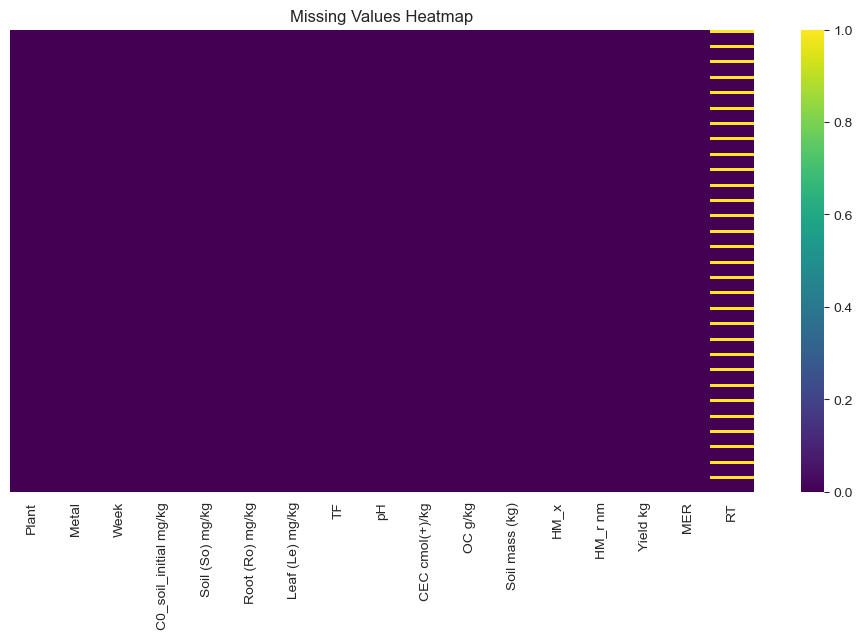

In [11]:
# Visuliztion of the missing value
plt.figure(figsize =(12,6))

sns.heatmap(
    df.isnull(),
    cbar = True,
    cmap = "viridis",
    yticklabels = False
)

plt.title("Missing Values Heatmap")
plt.show()

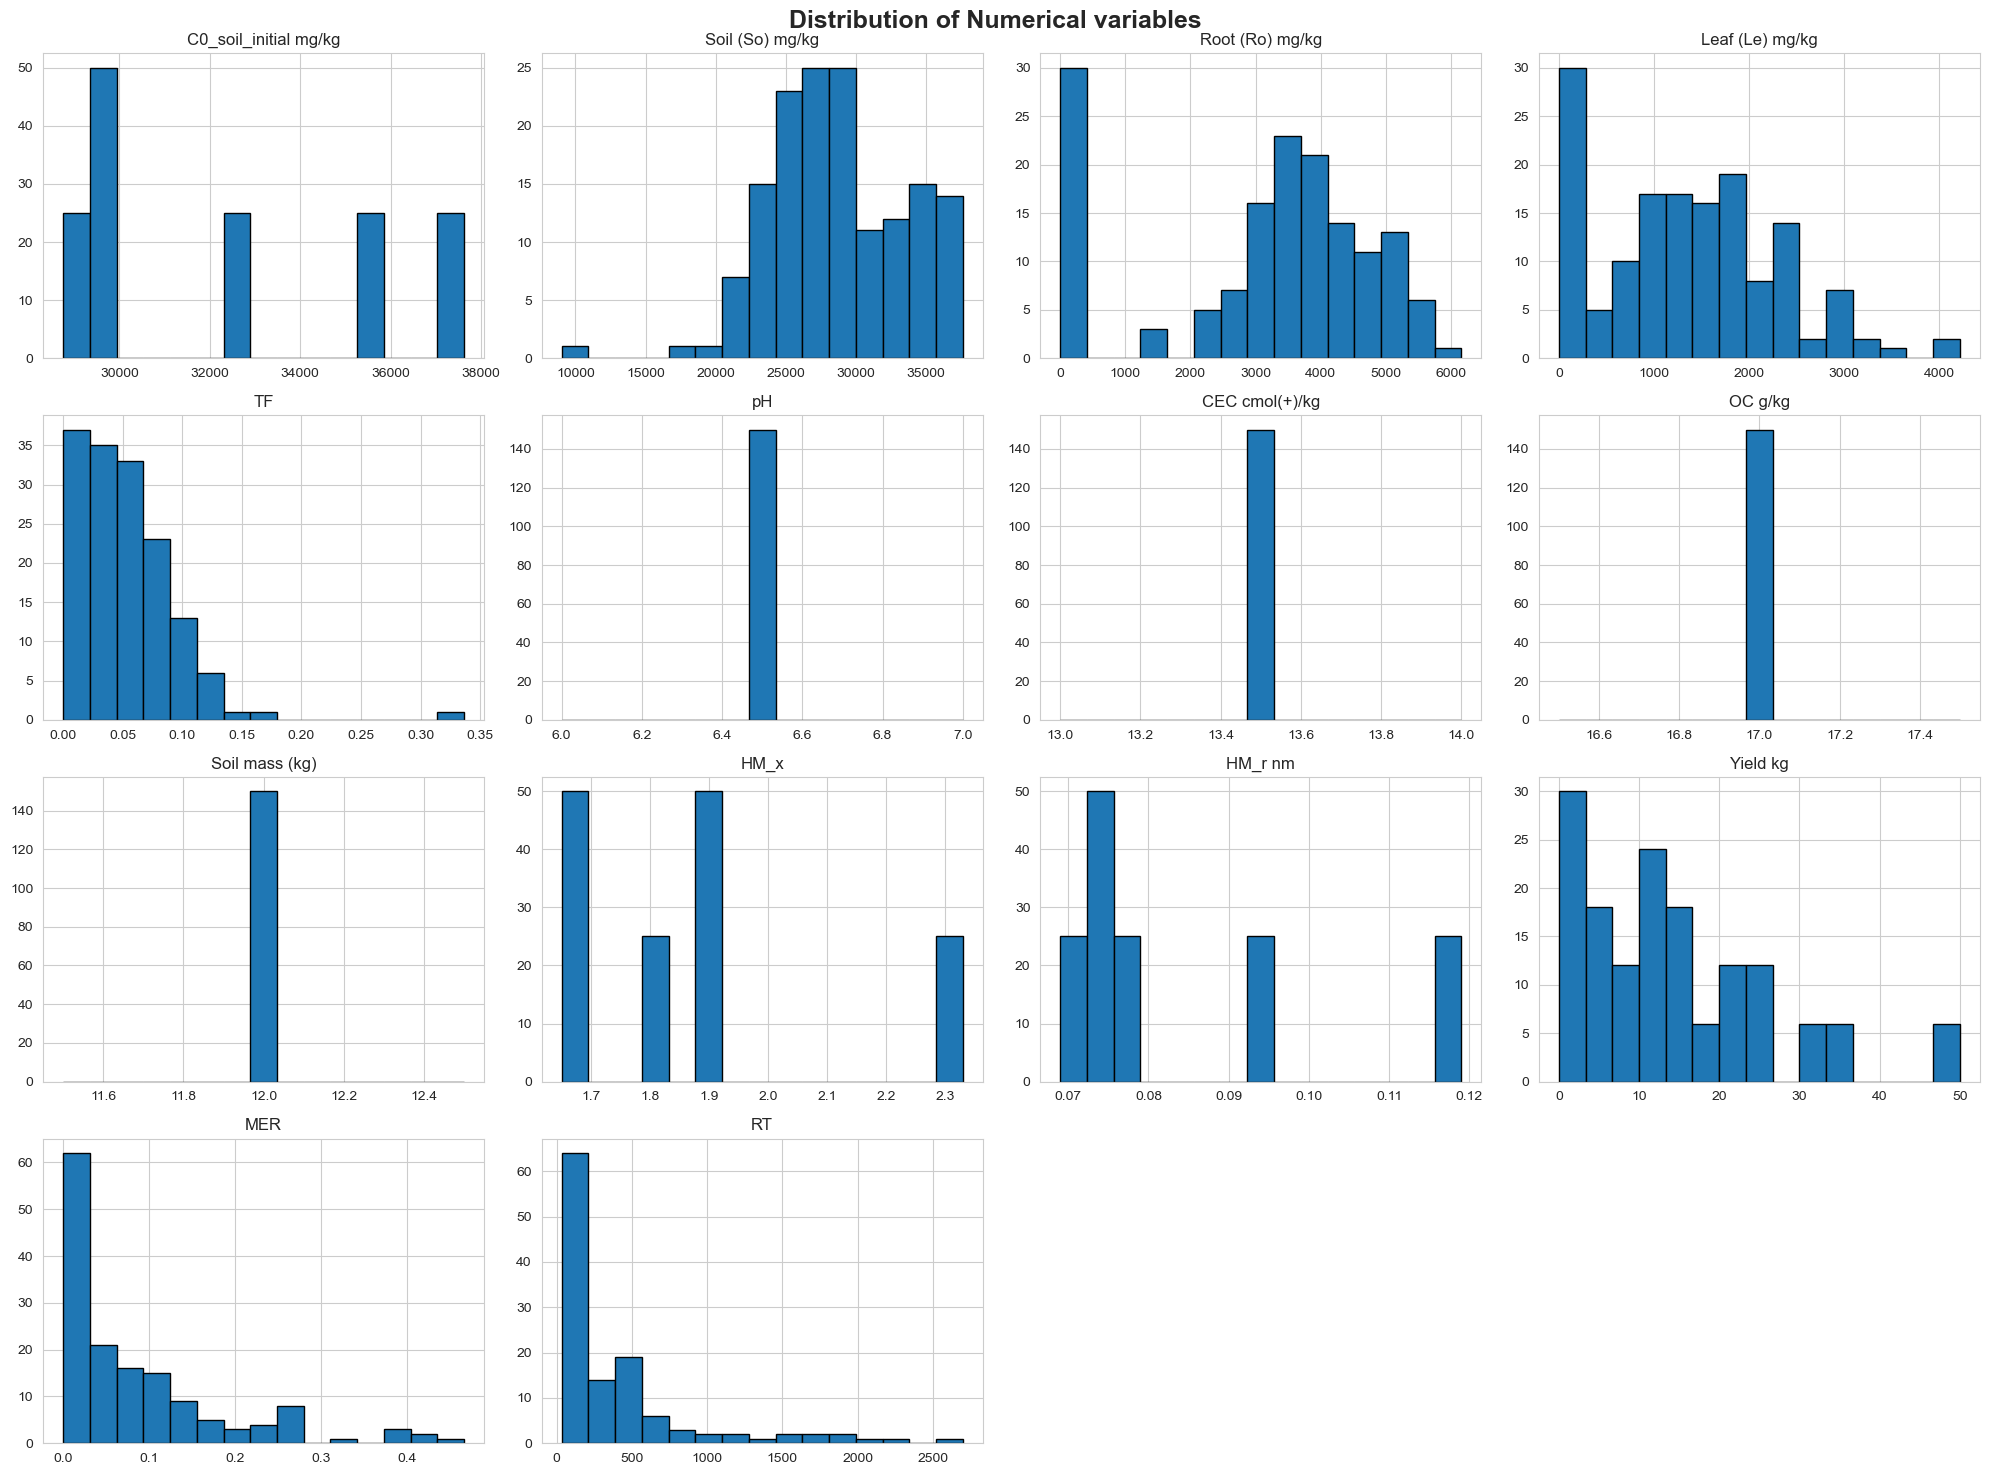

In [12]:
# Distribution of Numerical variables and creating histogram

# Selecting the numerical columns
numerical_cols = df.select_dtypes(include = ['float64', 'int64']).columns

# Histogram
df[numerical_cols].hist(
    figsize = (20, 15),
    bins = 15,
    edgecolor = 'black'
)
plt.suptitle("Distribution of Numerical variables", fontsize = 18, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Boxplots(Checking for Outliers)
plt.figure(figsize = (20, 15))

for i, column in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y = df[column])
    plt.title(column)

plt.suptitle("Boxplots(Checking for Outliers)", fontsize = 18, fontweight='bold')
plt.tight_layout()
plt.show()

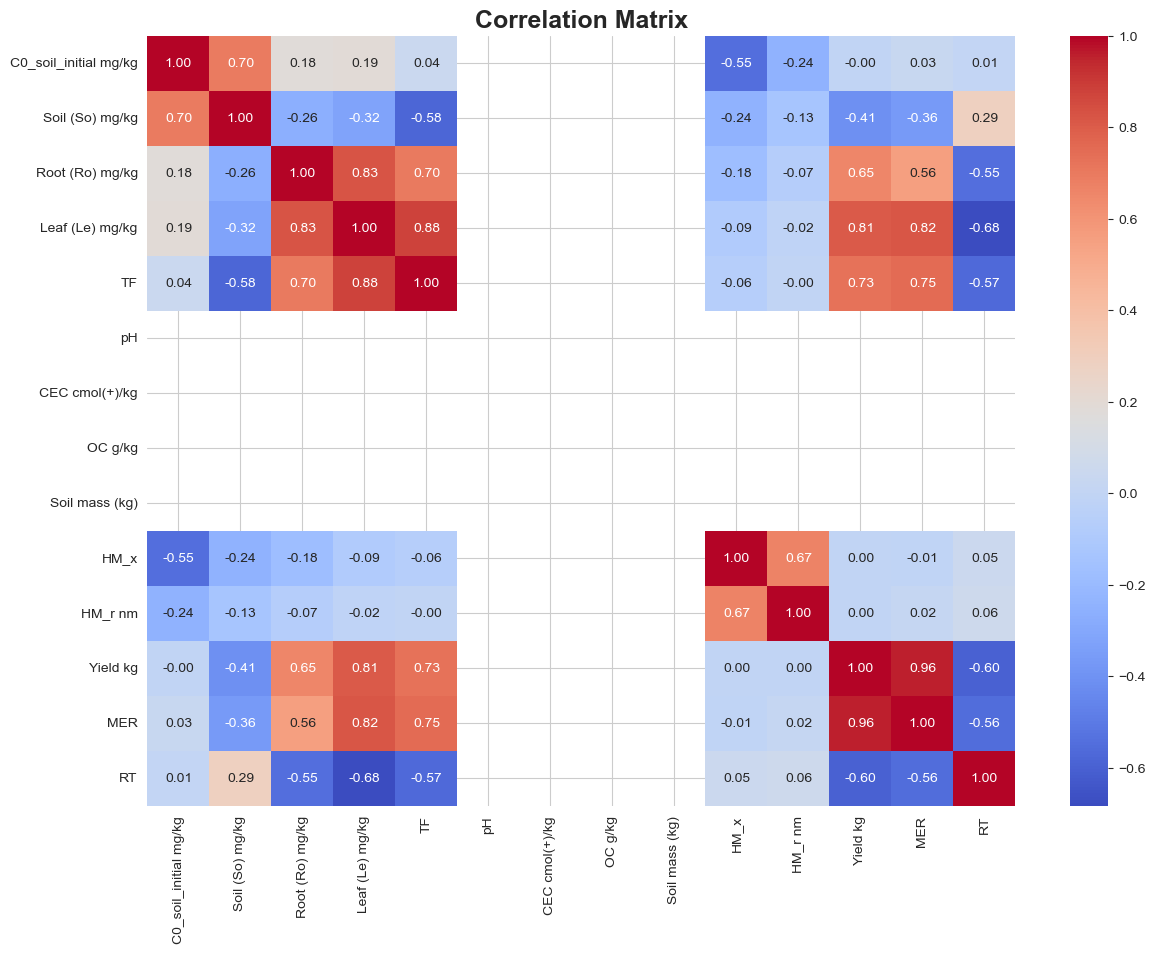

In [13]:
# Correlation Matrix
plt.figure(figsize = (14, 10))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    fmt = '.2f'
)

plt.title("Correlation Matrix", fontsize = 18, fontweight='bold')
plt.show()

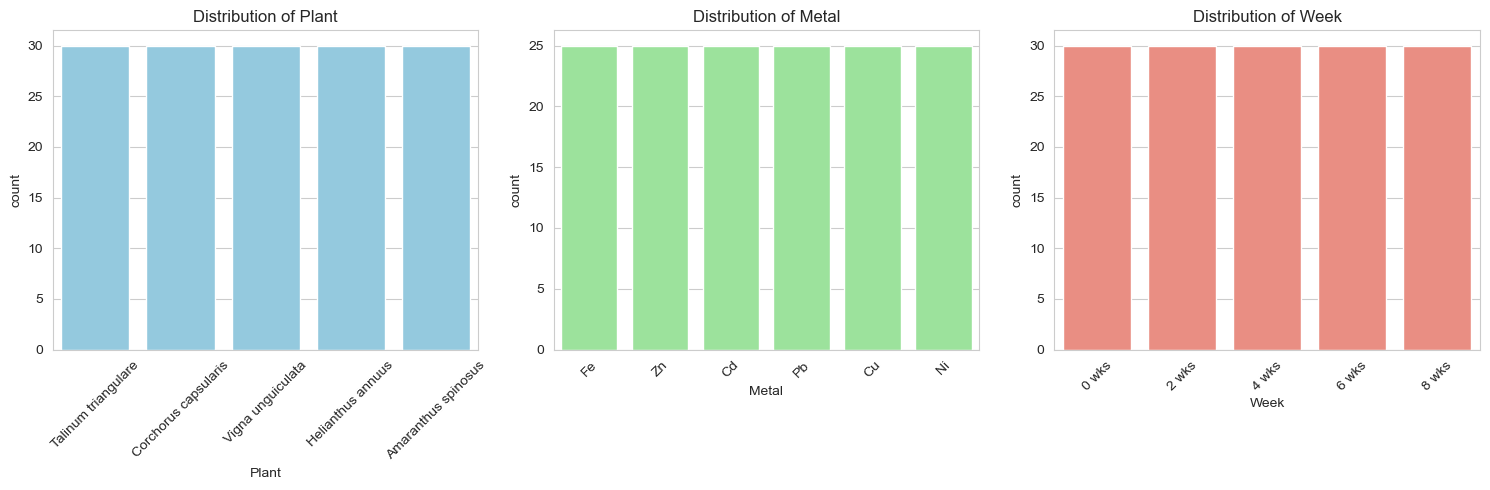

In [14]:
# Distribution of categorical variables
categorical_cols = ['Plant', 'Metal', 'Week']
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(15, 5))

for i, (col, color) in enumerate(zip(categorical_cols, colors), 1):
    plt.subplot(1, 3, i)

    sns.countplot(data=df, x=col, color=color)

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

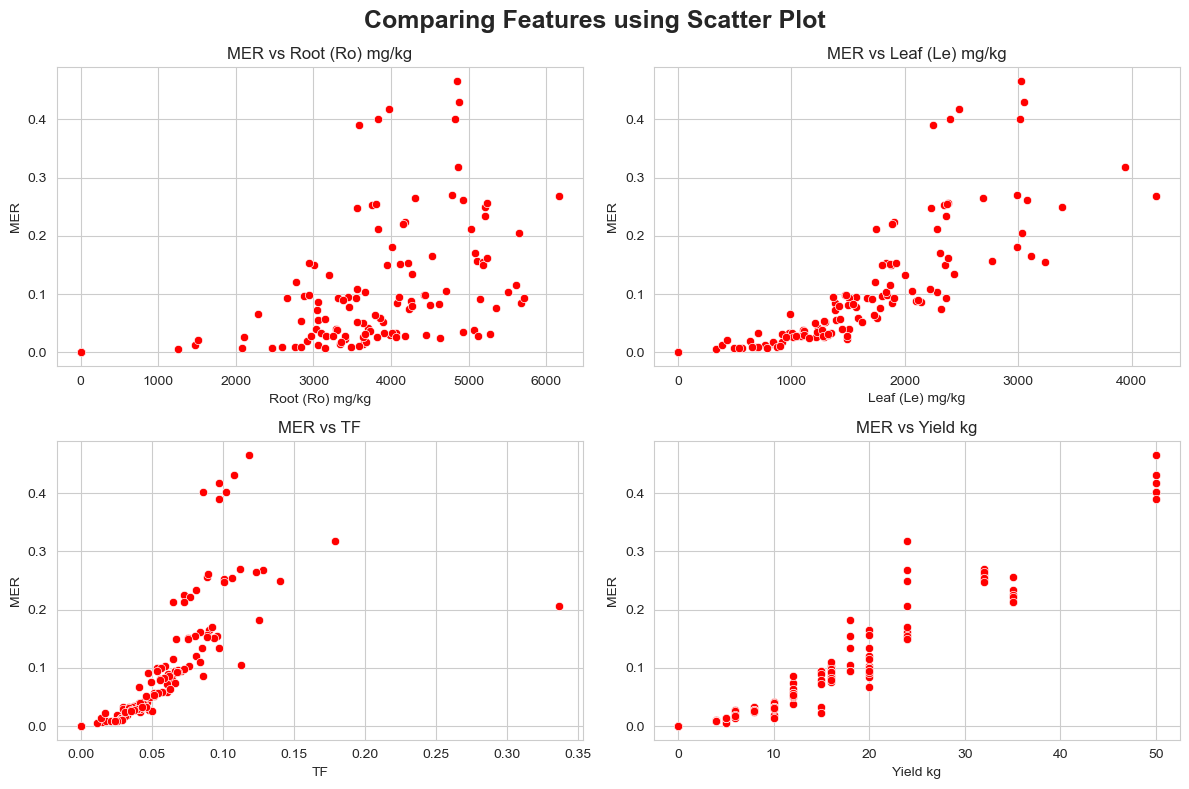

In [15]:
# Scatter Plot
important_feature = [
    'Root (Ro) mg/kg',
    'Leaf (Le) mg/kg',
    'TF',
    'Yield kg'
]

plt.figure(figsize=(12, 8))

for i, col in enumerate(important_feature, 1):
    plt.subplot(2, 2, i)

    sns.scatterplot(data=df, x=col, y='MER', c = "r")

    plt.title(f'MER vs {col}')
    plt.xlabel(col)
    plt.ylabel('MER')

plt.suptitle("Comparing Features using Scatter Plot", fontsize = 18, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preprocessing(RT as Target)

In [16]:
# Duel to the fact that the target variable RT has some missing value, we remove it.
# That si we remove the rows where RT is missing
df =df.dropna(subset = ["RT"])

print(df.shape)
print(df["RT"].isnull().sum())

(120, 17)
0


In [17]:
# Data preprocessing.
# This section introduced the neccessary features used in building the model

# Features and Target
# Feature
X = df.drop(columns = ['RT', 'Yield kg', 'MER', "TF"])

# Target
y = df["RT"]


print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nTarget (RT) basic stats:")
print(y.describe())

Features Shape: (120, 13)
Target Shape: (120,)

Target (RT) basic stats:
count     120.000000
mean      416.653667
std       512.784435
min        33.010000
25%       101.235000
50%       191.970000
75%       522.437500
max      2699.060000
Name: RT, dtype: float64


## Feature Engineering

In [18]:
# Identifying Numerical and Categorical Features

# Numerical Feature
numerical_cols = X.select_dtypes(include = ['float64', 'int64']).columns.tolist()

# Categorical Features
categorical_cols = X.select_dtypes(include = ['object']).columns.tolist()

print("Numerical Columns:\n")
print(numerical_cols)

print("\nCategorical Columns", categorical_cols)


Numerical Columns:

['C0_soil_initial mg/kg', 'Soil (So) mg/kg', 'Root (Ro) mg/kg', 'Leaf (Le) mg/kg', 'pH', 'CEC cmol(+)/kg', 'OC g/kg', 'Soil mass (kg)', 'HM_x', 'HM_r nm']

Categorical Columns ['Plant', 'Metal', 'Week']


## Feature Selection

In [19]:
# Createing The Preprocessor Pipeline to Standardize numerical value and to Encode Categorical values
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_cols ),
        ("cat", OneHotEncoder(handle_unknown = 'ignore'), categorical_cols)
    ]    
)

# Transform the Dataset
X_processed = preprocessor.fit_transform(X)
print('Processed Feature Shape:', X_processed.shape)

Processed Feature Shape: (120, 25)


## Train-Test Split

In [32]:
#  Split Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("Training Feature size:", X_train.shape)
print("Testing Feature size:", X_test.shape)
print("Training Target size:", y_train.shape)
print("Testing Target size:", y_test.shape)

Training Feature size: (96, 25)
Testing Feature size: (24, 25)
Training Target size: (96,)
Testing Target size: (24,)


In [33]:
# Applying K-Fold CV on the Training Set
# We Put K=5 fro the training set to create a more accurate CV
kfold = KFold(
    n_splits = 5,
    shuffle = True,
    random_state=42
)
print(kfold)

KFold(n_splits=5, random_state=42, shuffle=True)


## Model Building and Cross Validation

#### Creating All Four-Based Models using a pipeline
- Linear regression Model
- Decision Tree
- Random Forest
- XGBoost

In [34]:
# Creating a model pipeline for the models
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

}

print("✅ All Models Created Successfully")
print(models.keys())

✅ All Models Created Successfully
dict_keys(['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'])


### Model Comparison 

In [35]:
# Create an Empty container to the result of the 4 models
# ======================================================================v
results = []
trained_models = {}
predictions = {}
cv_results = {}

# Train, Validate and Evaluate Every Model
for model_name, model in models.items():
    print("=" * 70)
    print(f"Training {model_name}.....")
    print("=" * 70)
    
    # Train the models
    model.fit(X_train, y_train)

    # Save trained model
    trained_models[model_name] = model

    # Prediction of models
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    # Build the CV for the 3 models
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring="r2"
    )

    # Evaluation Metrics
    r2 = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    #Save Results
    results.append({
        "Model": model_name,
        "CV Mean R²": round(np.mean(cv_scores),4),
        "CV STD": round(np.std(cv_scores),4),
        "Test R²": round(r2,4),
        "MAE": round(mae,4),
        "RMSE": round(rmse,4),
        "MSE": round(mse,4)
    })
print("\n✅ Evaluation Completed")

# Comparison Table
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Test R²",
    ascending=False

)

comparison_df.reset_index(
    drop=True,
    inplace=True
)

print("="*90)
print("FINAL MODEL COMPARISON TABLE")
print("="*90)

display(comparison_df)
print("\n✅ Pipeline Completed Successfully!:")

Training Linear Regression.....
Training Decision Tree.....
Training Random Forest.....
Training XGBoost.....

✅ Evaluation Completed
FINAL MODEL COMPARISON TABLE


,Model,CV Mean R²,CV STD,Test R²,MAE,RMSE,MSE
0,XGBoost,0.6754,0.2586,0.9361,101.2310,150.4008,22620.3955
1,Decision Tree,0.5590,0.2793,0.9156,126.5079,172.8249,29868.4459
2,Random Forest,0.8097,0.0513,0.8659,129.1698,217.8024,47437.8907
3,Linear Regression,0.5924,0.0884,0.7356,225.5348,305.8236,93528.0463



✅ Pipeline Completed Successfully!:


### Select Best Model

In [36]:
# ============================================================
# STEP 10A: Select Best Model
# ============================================================

best_model_name = comparison_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*70)

print(f"🏆 Best Model: {best_model_name}")

print("="*70)

display(comparison_df.head(1))

🏆 Best Model: XGBoost


,Model,CV Mean R²,CV STD,Test R²,MAE,RMSE,MSE
0,XGBoost,0.6754,0.2586,0.9361,101.231,150.4008,22620.3955


## Feature importance

In [47]:
# Check the mismatch
print("X columns count:", len(X.columns))
print("Feature importances count:", len(best_model.feature_importances_))

X columns count: 13
Feature importances count: 25


In [49]:
# Check what best_model actually is
print(type(best_model))
print("\nFeature importances count:", len(best_model.feature_importances_))
print("X columns count:", len(X.columns))

<class 'xgboost.sklearn.XGBRegressor'>

Feature importances count: 25
X columns count: 13


In [50]:
# ============================================================
# STEP 11A: Extract Feature Importance (Fixed)
# ============================================================

# Get feature names from the preprocessor directly (not from pipeline)
num_features = numerical_cols

# Get OneHotEncoded feature names from the preprocessor
cat_features = preprocessor.named_transformers_['cat']\
                            .get_feature_names_out(categorical_cols).tolist()

# Combine both
all_feature_names = num_features + cat_features

print("Total feature names:", len(all_feature_names))
print("Total importances:", len(best_model.feature_importances_))

Total feature names: 25
Total importances: 25


In [51]:
# Build the feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature"   : all_feature_names,
    "Importance": best_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)
display(feature_importance)

FEATURE IMPORTANCE


,Feature,Importance
0,Leaf (Le) mg/kg,0.815860
1,Soil (So) mg/kg,0.042702
2,Week_2 wks,0.034518
3,Root (Ro) mg/kg,0.025497
4,Metal_Cu,0.020147
5,Plant_Vigna unguiculata,0.014219
6,Week_6 wks,0.011500
7,Plant_Helianthus annuus,0.008988
8,Plant_Talinum triangulare,0.006319
9,C0_soil_initial mg/kg,0.005906


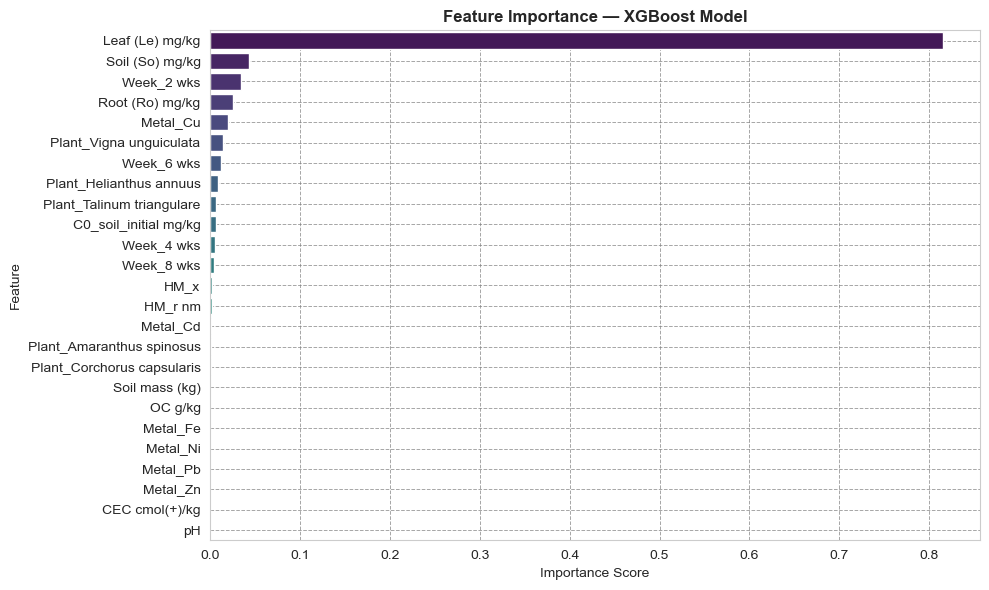

In [57]:
# ── Visualize Feature Importance ────────────────────────────
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance — XGBoost Model", fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.grid(axis='both', linestyle='--', linewidth=0.7, alpha=0.7, color='gray')
plt.gca().set_axisbelow(True)
plt.show()

### Model Interpretation

In [58]:
#  Actual vs Predicted Values
# Predict using the Best Model (XGBoost)

y_pred_best = best_model.predict(X_test)

print("="*70)
print("First 10 Actual vs Predicted Values")
print("="*70)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_best
})

display(comparison.head(10))

First 10 Actual vs Predicted Values


,Actual,Predicted
56,879.12,1175.963989
59,100.29,101.958382
6,2197.80,1852.548584
69,148.79,140.555649
33,99.26,93.858040
81,1619.43,1336.528687
92,168.88,250.079117
13,469.04,712.295654
51,831.60,545.633240
134,58.01,68.122711


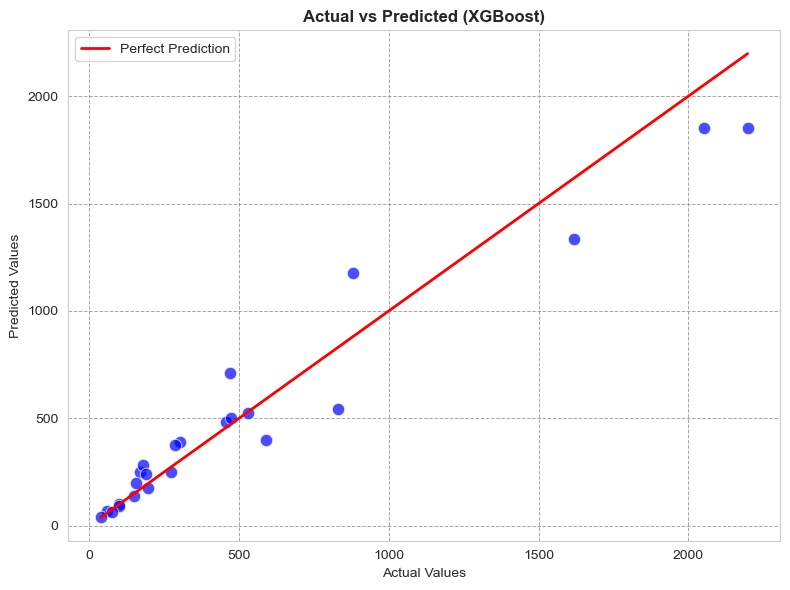

In [61]:
# ── Actual vs Predicted Plot (Seaborn) ──────────────────────
plt.figure(figsize=(8, 6))

# Scatter plot using seaborn
sns.scatterplot(
    x=y_test,
    y=y_pred_best,
    color="blue",
    alpha=0.7,
    edgecolor="white",
    s=80
)

# Perfect prediction line
sns.lineplot(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (XGBoost)", fontweight='bold')
plt.legend()

# Add both horizontal and vertical gridlines
plt.grid(axis='both', linestyle='--', linewidth=0.7, alpha=0.7, color='gray')
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

In [62]:
# ==========================================================
# STEP 12C: Best Model Performance
# ==========================================================

print("="*70)
print("BEST MODEL PERFORMANCE")
print("="*70)

print(f"Model : {best_model_name}")
print(f"R² Score : {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred_best):.4f}")

print("="*70)

BEST MODEL PERFORMANCE
Model : XGBoost
R² Score : 0.9361
MAE : 101.2310
RMSE : 150.4008
MSE : 22620.3955


In [64]:
# ============================================================
# STEP 13A: Calculate Residuals
# ============================================================

# Residual = Actual - Predicted
residuals = y_test - y_pred_best

print("="*70)
print("Residuals Calculated Successfully")
print("="*70)

print(residuals[:10])

Residuals Calculated Successfully
56    -296.843989
59      -1.668382
6      345.251416
69       8.234351
33       5.401960
81     282.901313
92     -81.199117
13    -243.255654
51     285.966760
134    -10.112711
Name: RT, dtype: float64


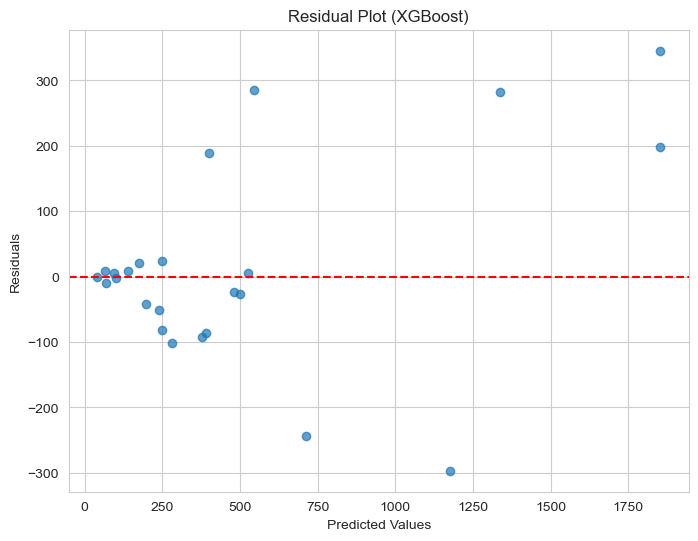

In [65]:
#Residual Plot
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(f"Residual Plot ({best_model_name})")

plt.grid(True)

plt.show()

### Save the model for reuse

In [66]:
# ============================================================
#  Save the Best Model
# ============================================================

import joblib

# Save the best model
joblib.dump(best_model, "best_xgboost_model.pkl")

print("="*70)
print("✅ Best Model Saved Successfully!")
print("Model Name:", best_model_name)
print("File Saved As: best_xgboost_model.pkl")
print("="*70)

✅ Best Model Saved Successfully!
Model Name: XGBoost
File Saved As: best_xgboost_model.pkl


In [67]:
# ============================================================
# Load the Saved Model
# ============================================================

loaded_model = joblib.load("best_xgboost_model.pkl")

print("="*70)
print("✅ Model Loaded Successfully!")
print("Loaded Model:", loaded_model)
print("="*70)

✅ Model Loaded Successfully!
Loaded Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [68]:
# ============================================================
#  Test Loaded Model
# ============================================================

loaded_predictions = loaded_model.predict(X_test)

print("="*70)
print("First 10 Predictions")
print("="*70)

print(loaded_predictions[:10])

First 10 Predictions
[1175.964    101.95838 1852.5486   140.55565   93.85804 1336.5287
  250.07912  712.29565  545.63324   68.12271]


### Testing the Model to check if the can predict the actual using the test dataset

In [69]:
# ============================================================
#  Select 5 Unseen Samples
# ============================================================

# Select the first 5 samples from the test set
new_data = X_test[:5]

# Actual RT values
actual_values = y_test[:5]

print("="*70)
print("Selected 5 unseen samples successfully.")
print("="*70)

Selected 5 unseen samples successfully.


In [72]:
# ============================================================
#  Predict RT Using the Saved Model
# ============================================================

predicted_values = loaded_model.predict(new_data)

print("="*70)
print("Prediction Completed Successfully")
print("="*70)

print(predicted_values)

Prediction Completed Successfully
[1175.964    101.95838 1852.5486   140.55565   93.85804]


In [73]:
# ============================================================
#  Compare Actual vs Predicted
# ============================================================

comparison = pd.DataFrame({

    "Actual RT": actual_values,
    "Predicted RT": predicted_values

})

comparison["Absolute Error"] = abs(
    comparison["Actual RT"] -
    comparison["Predicted RT"]
)

display(comparison)

,Actual RT,Predicted RT,Absolute Error
56,879.12,1175.963989,296.843989
59,100.29,101.958382,1.668382
6,2197.80,1852.548584,345.251416
69,148.79,140.555649,8.234351
33,99.26,93.858040,5.401960
